# GET MNIST Data

In [1]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml("mnist_784",as_frame=False)

'''
The sklearn.datasets package contains mostly three types of functions: fetch_* functions
such as fetch_openml() to download real-life datasets, load_* functions to load small toy
datasets bundled with Scikit-Learn (so they don’t need to be downloaded over the internet), and
make_* functions to generate fake datasets, useful for tests
'''

'\nThe sklearn.datasets package contains mostly three types of functions: fetch_* functions\nsuch as fetch_openml() to download real-life datasets, load_* functions to load small toy\ndatasets bundled with Scikit-Learn (so they don’t need to be downloaded over the internet), and\nmake_* functions to generate fake datasets, useful for tests\n'

In [2]:
# it Returns the input in Pandas Dataframe and Label in Pandas in Series
X,y = mnist.data,mnist.target
X

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [3]:
X.shape

(70000, 784)

In [4]:
y

array(['5', '0', '4', ..., '4', '5', '6'], dtype=object)

In [5]:
y.shape

(70000,)

### Each Image has 784 Features as each image is 28x28 pixels lets see one of the image

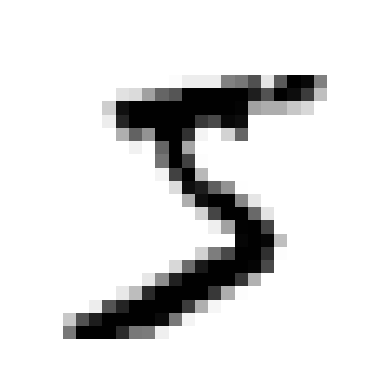

In [6]:
import matplotlib.pyplot as plt

def plot_digit(image_data):
  image = image_data.reshape(28,28)
  plt.imshow(image,cmap="binary") # for black and white so binary
  plt.axis("off")

some_digit = X[0]
plot_digit(some_digit)
plt.show()

In [7]:
y[0]

'5'

### So it was 5

In [8]:
# our data is already split from fetch_openmal()

X_train,X_test,y_train,y_test = X[:60000],X[60000:],y[:60000],y[60000:]


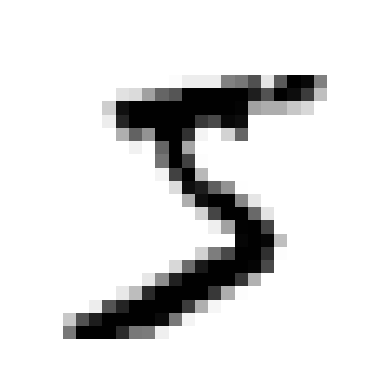

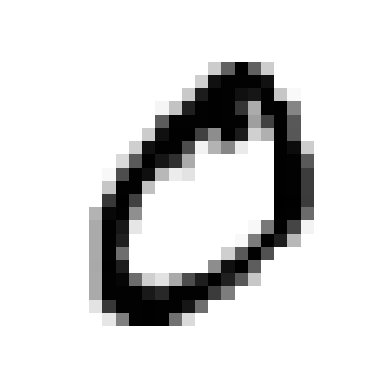

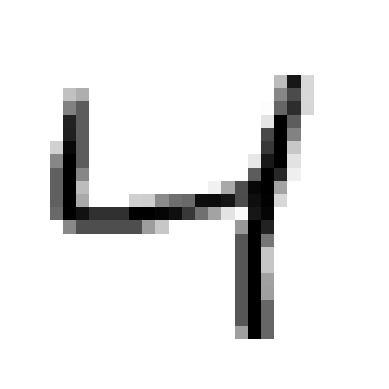

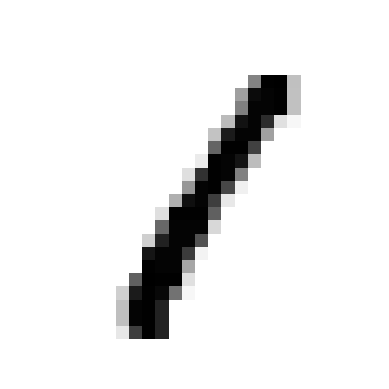

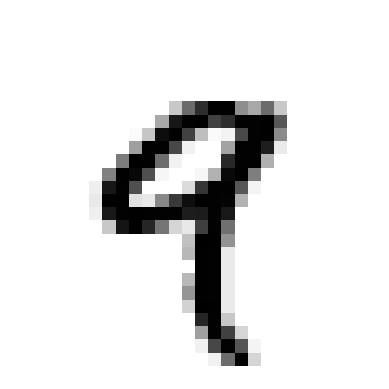

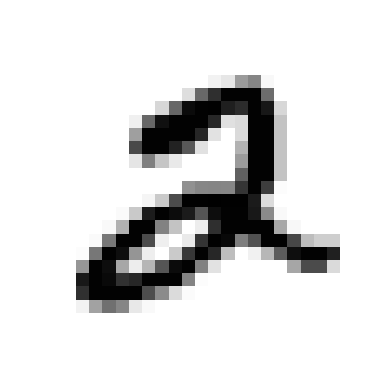

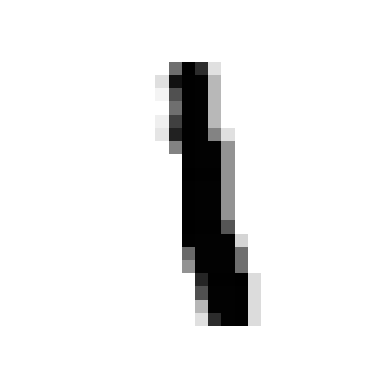

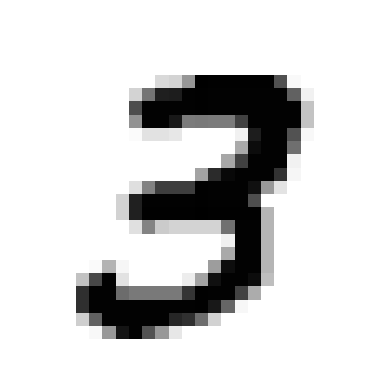

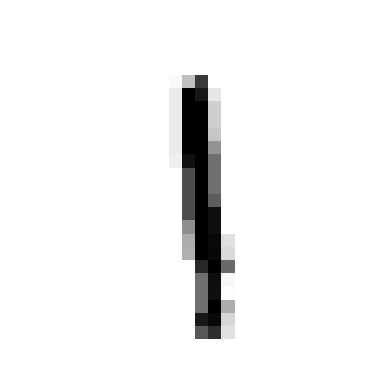

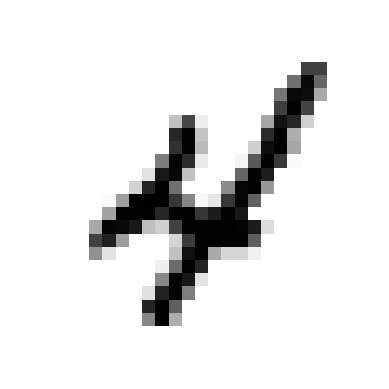

In [9]:
for (i,data) in enumerate(X_train[:10]):
  plot_digit(data)
  plt.show()


# Training a Binary Classifier

### we will simplipy the problem and try to check only one digit 5-detctor is it 5 or not 5

In [10]:
y_train_5 = (y_train == '5') # return True for indexs were element is 5 else false
y_test_5 = (y_test == '5')
y_train_5

array([ True, False, False, ...,  True, False, False])

In [11]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train,y_train_5)

SGDClassifier(random_state=42)

### Now Lets test the model that does it can detect 5

In [12]:
sgd_clf.predict(X_train[:50])

array([ True, False, False, False, False, False, False, False, False,
       False, False,  True, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False,  True,
       False, False, False, False, False, False, False, False, False,
       False, False,  True,  True, False])

In [13]:
y_train[:50]

array(['5', '0', '4', '1', '9', '2', '1', '3', '1', '4', '3', '5', '3',
       '6', '1', '7', '2', '8', '6', '9', '4', '0', '9', '1', '1', '2',
       '4', '3', '2', '7', '3', '8', '6', '9', '0', '5', '6', '0', '7',
       '6', '1', '8', '7', '9', '3', '9', '8', '5', '9', '3'],
      dtype=object)

# Performance Measures

#### often Evaluating a Classifier is Much Tricker than Evaluating a Regressor

## Measuring Accuracy using Cross-Validation

In [14]:
from sklearn.model_selection import cross_val_score
cross_val_score(sgd_clf,X_train,y_train_5,cv=3,scoring="accuracy")

array([0.95035, 0.96035, 0.9604 ])

### The accuracy is too much more than 95% lets use a dummy classifier which classifies every image in to its most frequent class which in this case is -ve class non-5

In [15]:
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier()
dummy_clf.fit(X_train,y_train_5)
dummy_clf.predict(X_train)

array([False, False, False, ..., False, False, False])

In [16]:
cross_val_score(dummy_clf,X_train,y_train_5,cv=3,scoring="accuracy")

array([0.90965, 0.90965, 0.90965])

### This is Bcoz more than 90% image is non 5 so it tells that for classification model to measure performace, accuracy is not a correct thing we need to use confusion matrix

## Confusion Matrix

In [17]:
## Here we will use cross val predict as it returns predictions after k-fold crossvalidation
from sklearn.model_selection import cross_val_predict
y_train_predict = cross_val_predict(sgd_clf,X_train,y_train_5,cv=3)

In [18]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_train_5,y_train_predict)
cm

array([[53892,   687],
       [ 1891,  3530]])

### Here first row first column represnts how many negative class e.g non-5 were detected correctly that is 53892 in second column it shows how many non-5 are detecd as 5 so falsly positive and the second row first column tells how many 5's are detected as non-5 e.g true-negative in the second column it tells how many 5 are correctly detected as 5 positive case which is 3530. so the perfect classifier model should have only +ve and -ve and false+ve and true-ve should be going towards 0.

In [19]:
# lets check what will be perfect
y_train_predict_predictions = y_train_5 # peretinding we reach perfections
confusion_matrix(y_train_5,y_train_predict_predictions)

array([[54579,     0],
       [    0,  5421]])

## Precision and Recall

### precision = TP/(FP+TP)  means out of all the 5 predicted out of that how many are truely 5

### recall = TP/(FN+TP) means out of all 5 how many were truly detected as 5

In [20]:
from sklearn.metrics import precision_score,recall_score
precision_score(y_train_5,y_train_predict)

0.8370879772350012

In [21]:
recall_score(y_train_5,y_train_predict)

0.6511713705958311

In [23]:
from sklearn.metrics import f1_score
f1_score(y_train_5,y_train_predict)

0.7325171197343847

## Precision recall Trade/Off

In [24]:
y_scores = sgd_clf.decision_function([X_train[0]])
y_scores

array([2164.22030239])

In [26]:
thresold = 0
(y_scores > thresold)

array([ True])

In [34]:
thresold = 3000
(y_scores > thresold)

array([False, False, False, ...,  True, False, False])

In [35]:
y_scores = cross_val_predict(sgd_clf,X_train,y_train_5,cv=3,method="decision_function")

In [36]:
from sklearn.metrics import precision_recall_curve
precisions,recalls,thresolds = precision_recall_curve(y_train_5,y_scores)

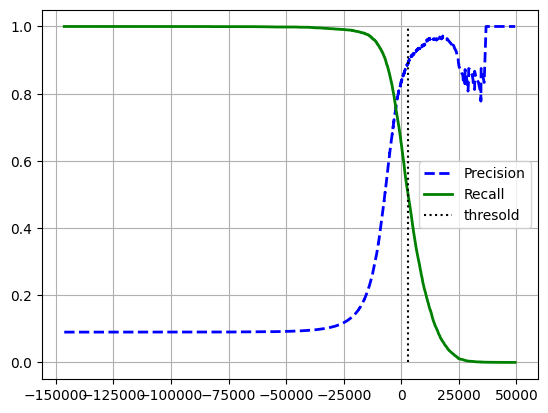

In [41]:
plt.plot(thresolds,precisions[:-1],"b--",label="Precision",linewidth=2)
plt.plot(thresolds,recalls[:-1],"g-",label="Recall",linewidth=2)
plt.vlines(thresold,0,1.0,"k","dotted",label="thresold")
plt.grid()
plt.legend()
plt.show()


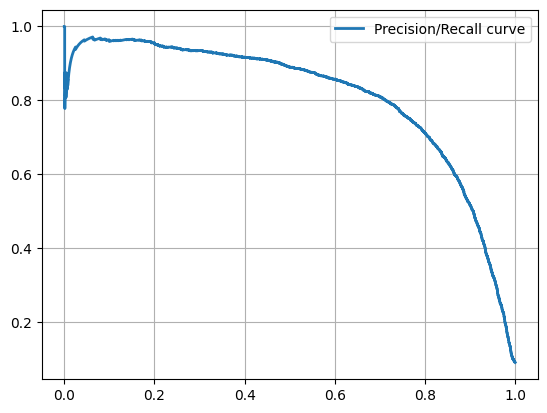

In [46]:
plt.plot(recalls,precisions,linewidth=2,label="Precision/Recall curve")
plt.grid()
plt.legend()
plt.show()

In [48]:
precisions[:-1]

array([0.09035   , 0.09035151, 0.09035301, ..., 1.        , 1.        ,
       1.        ])

In [49]:
## Lets Say we want around 90% precision
idx_for_90_precision = (precisions >= 0.90).argmax()
threshold_for_90_precision = thresolds[idx_for_90_precision]
threshold_for_90_precision


np.float64(3370.0194991439557)

In [51]:
y_train_pred_5 = (y_scores >= threshold_for_90_precision)

In [52]:
## Now Lets See its Precision , Recall
precision_score(y_train_5,y_train_pred_5)

0.9000345901072293

In [53]:
recall_score(y_train_5,y_train_pred_5)

0.4799852425751706

#### As We can See That as The Precision The Recall Gradually Gone Down

## The ROC Curve